(256, 256)


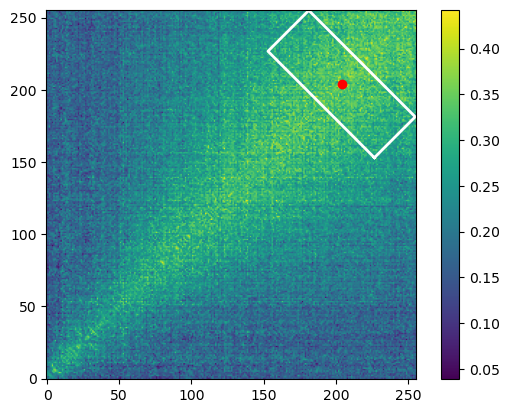

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
import pickle
from reshape_funs import diagonal_resample_square
matfile = "D2_A_170C_B1_batch001_q009_phi001_twotimeresult.mat"
M = scipy.io.loadmat(matfile)["C"]
Mp = resize(M,(256,256),anti_aliasing=True)
print(np.shape(Mp))
im = plt.imshow(Mp, origin='lower')
plt.colorbar(im)
Mrot, xp, yp, x0, y0, xpmax, corners, boundary = diagonal_resample_square(
    Mp, frac=0.80, half_size=20, dx=1.0
)
plt.plot(boundary[:, 0], boundary[:, 1], 'w-', linewidth=2)
plt.plot(x0, y0, 'ro')
plt.show()

Normalization value = 0.346


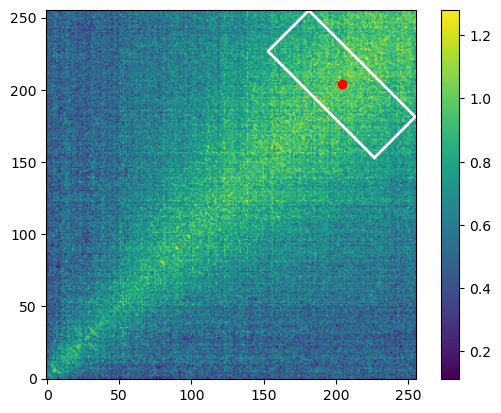

In [2]:
# yp is your column-averaged profile and xp is the corresponding coordinate array
yp = np.average(Mrot, axis=0)
nx = Mrot.shape[1]
xp = np.arange(nx) - nx / 2

from reshape_funs import fit_ridge_amplitude

# Fit the ridge and obtain the normalization value
ymean = fit_ridge_amplitude(
    xp,
    yp,
    ridge_width=24,
    cen_width=2,
    make_plot=False
)

print("Normalization value = {:4.3f}".format(ymean))

# Normalize the image
Mout = Mp / ymean

plt.figure()
im = plt.imshow(Mout, origin='lower')
plt.plot(boundary[:, 0], boundary[:, 1], 'w-', linewidth=2)
plt.plot(x0, y0, 'ro')
plt.colorbar(im)